#### Standard Visualizations in statistics

In [1]:
import math
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

from grid_determination_bizom.constant import COLS_TO_KEEP
from grid_determination_bizom.data_pipeline.data_aggregation import DataAggregator

In [2]:
FILE_PATH = "/Users/saranyapal/Developer/grid-determination-bizom/data/delhi_grids.csv"
df = pd.read_csv(FILE_PATH)
df.shape

(2000, 14)

In [3]:
transformer = DataAggregator(df)
X_scaled, full_df = transformer()

Extracting Image Features: 100%|██████████| 2000/2000 [00:02<00:00, 809.88it/s]


In [4]:
print(X_scaled.shape)
print()
print("=" * 15)
print(full_df.columns)

(2000, 8)

Index(['grid_id', 'latitude', 'longitude', 'building_count',
       'yellow_building_count', 'building_density', 'yellow_building_density',
       'total_building_density', 'main_road_density', 'local_road_density',
       'total_road_density', 'waterbody', 'water_percent', 'empty',
       'usable_area_percent', 'kirana_potential_index',
       'yellow_building_proportion', 'local_road_proportion',
       'avg_yellow_building_size', 'water_percent_log',
       'kirana_potential_index_log', 'dist_to_nearest_hub',
       'green_cover_ratio', 'edge_density', 'structural_complexity',
       'market_activity_index', 'street_exposure_index'],
      dtype='str')


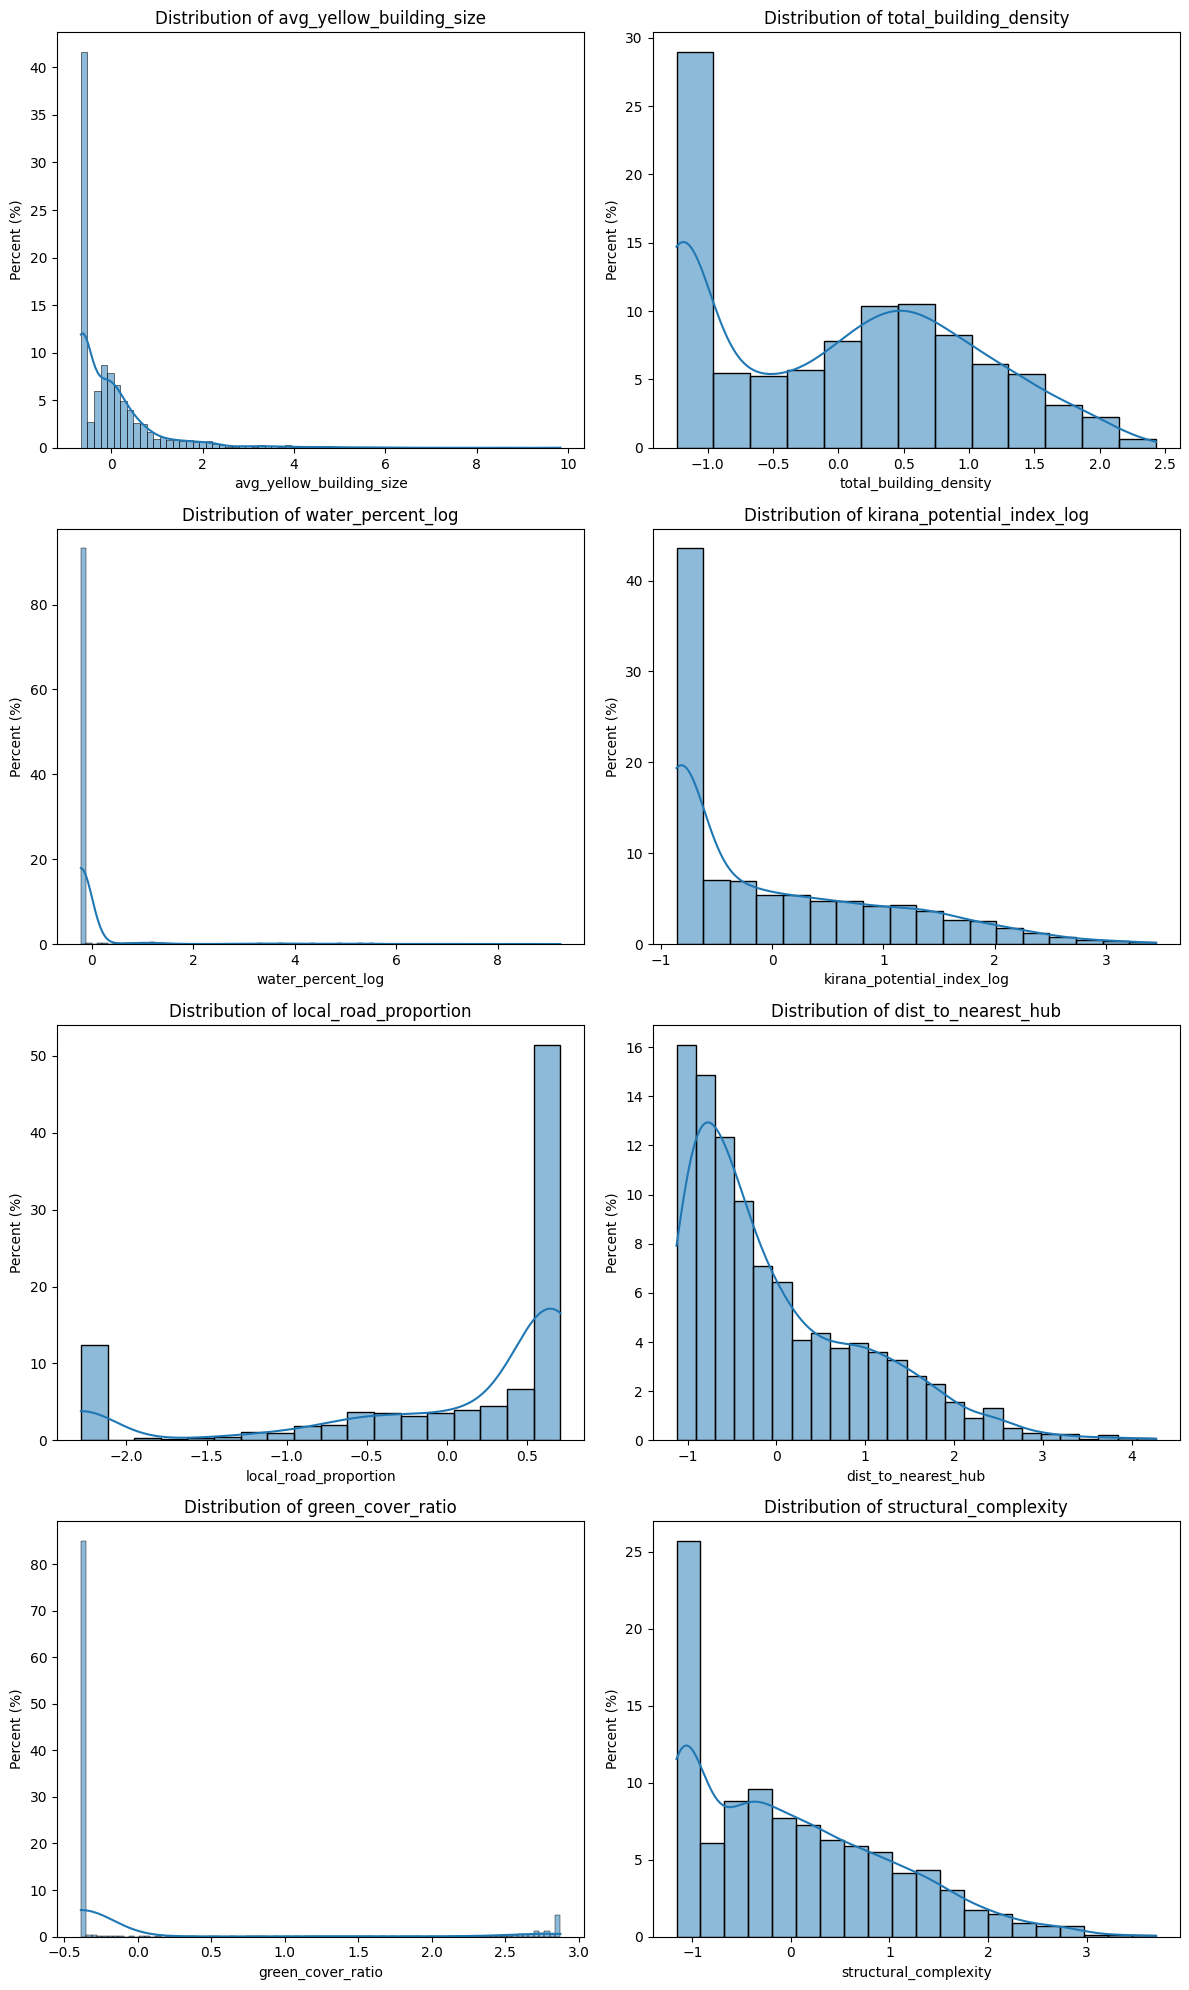

In [5]:
#   Distribution of Finalized features
X_scaled_df = pd.DataFrame(X_scaled, columns=COLS_TO_KEEP)
num_cols = len(X_scaled_df.columns)
num_rows = math.ceil(num_cols / 2)

fig, axes = plt.subplots(num_rows, 2, figsize=(12, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(X_scaled_df.columns):
    sns.histplot(data=X_scaled_df, x=col, kde=True, ax=axes[i], stat="percent")

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Percent (%)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [6]:
X_scaled_df.corr()

,avg_yellow_building_size,total_building_density,water_percent_log,kirana_potential_index_log,local_road_proportion,dist_to_nearest_hub,green_cover_ratio,structural_complexity
avg_yellow_building_size,1.000000,0.380506,-0.056983,0.647210,0.129837,-0.209519,-0.255298,0.099088
total_building_density,0.380506,1.000000,-0.091271,0.508221,0.478094,-0.446988,-0.466760,0.760482
water_percent_log,-0.056983,-0.091271,1.000000,-0.037116,-0.055836,-0.050968,0.020125,-0.051709
kirana_potential_index_log,0.647210,0.508221,-0.037116,1.000000,0.161892,-0.322597,-0.328264,0.289042
local_road_proportion,0.129837,0.478094,-0.055836,0.161892,1.000000,-0.194280,-0.348355,0.468727
dist_to_nearest_hub,-0.209519,-0.446988,-0.050968,-0.322597,-0.194280,1.000000,0.255816,-0.385921
green_cover_ratio,-0.255298,-0.466760,0.020125,-0.328264,-0.348355,0.255816,1.000000,-0.424744
structural_complexity,0.099088,0.760482,-0.051709,0.289042,0.468727,-0.385921,-0.424744,1.000000


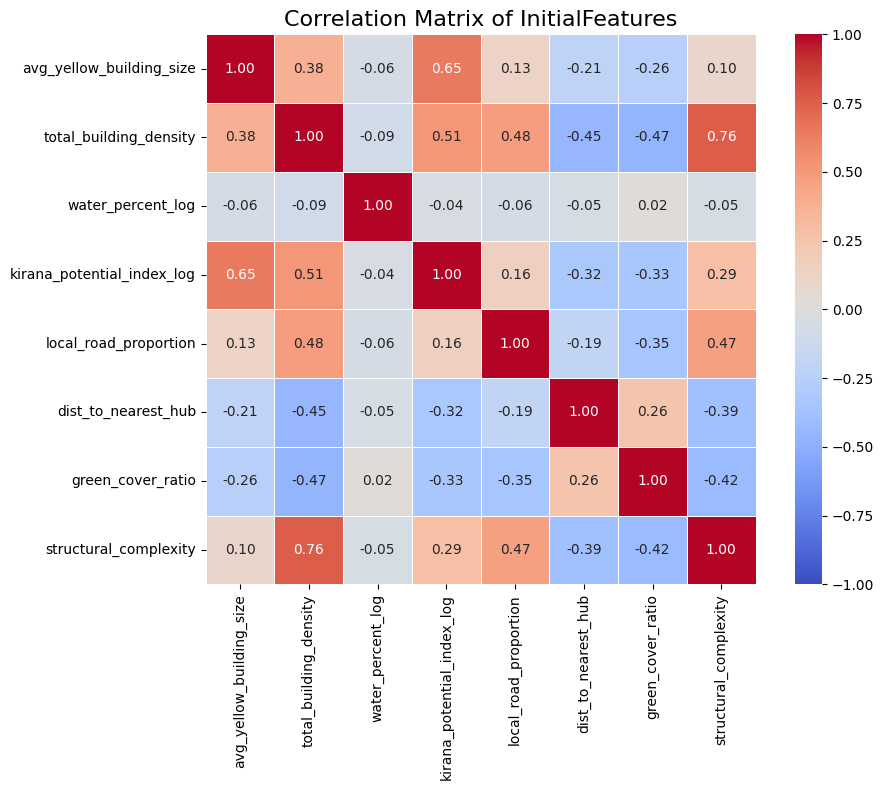

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    X_scaled_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("Correlation Matrix of InitialFeatures", fontsize=16)
plt.tight_layout()

In [8]:
#   Clustering and PCA

gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
labels = gmm.fit_predict(X_scaled)
probs = gmm.predict_proba(X_scaled)

full_df["labels"] = labels
for i in range(probs.shape[1]):
    full_df[f"prob_cluster_{i}"] = probs[:, i]

In [9]:
full_df["labels"].value_counts()

labels
1    1311
2     581
0     108
Name: count, dtype: int64

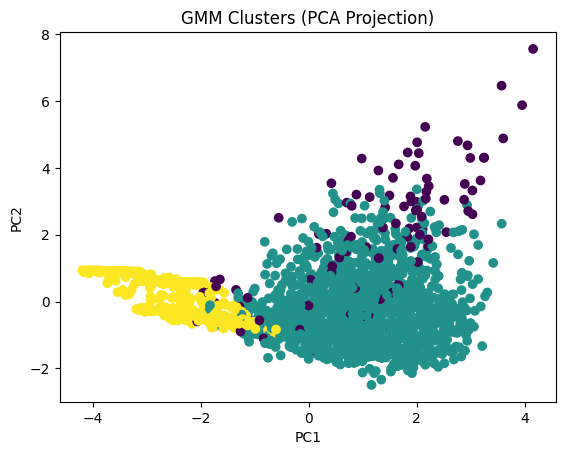

In [10]:
#   Visualization of clustering and PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters (PCA Projection)")
plt.show()